In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import logsumexp
import time

In [2]:
heston_params_dict = {
    'μ': 0.02,
    'κ': 1.5,
    'θ': 0.05,
    'λ': 0.18,
    'ρ': 0.5,
    'v_0': 0.04
}

param_names = ['μ', 'κ', 'θ', 'λ', 'ρ', 'v_0']

We define a function to simulate the Heston SDE that allows for a choice of either the Euler or IMEX discretization method. In our analysis, we will use the Euler method to simulate stock returns for the Extended Kalman Filter, while the IMEX method will be used to simulate returns for the Particle Filter. The IMEX method follows the Heston IMEX method specified in Lecture 12 slides.

In [3]:
def simulate_log_stock_process(method, S0, n_periods, heston_params):

    μ, κ, θ, λ, ρ, v0 = heston_params

    dt = (1/252)

    v = np.zeros(n_periods)
    y = np.zeros(n_periods)
    
    z1 = np.random.randn(n_periods)
    z2 = np.random.randn(n_periods)

    if method == 'euler':
        Σ = np.array([
            [1, ρ],
            [ρ, 1]
        ])

        L = np.linalg.cholesky(Σ)
        Z = L @ np.vstack([z1,z2])
        z_stock = Z[0]*np.sqrt(dt)
        z_vol = Z[1]*np.sqrt(dt)

    
    for t in range(n_periods):
        
        if t == 0:
            v[t] = v0
            y[t] = np.log(S0)
        else:
            if method == 'imex':
                num = v[t-1] + κ*(θ-v[t-1])*dt + λ*ρ*(0.5*v[t-1]*dt) + \
                λ*np.sqrt(v[t-1]*(1-ρ**2))*np.sqrt(dt)*z1[t-1] + \
                λ*ρ*np.sqrt(v[t-1]*dt)*z2[t-1]
                
                denom = (1 + 0.5*λ*ρ*dt)
                
                v[t] = num / denom
        
                y[t] = y[t-1] + (μ - 0.5*v[t])*dt + np.sqrt(v[t-1]*dt)*z2[t-1]
                
            elif method == 'euler':
                dv = κ*(θ-v[t-1])*dt + λ*np.sqrt(v[t-1])*z_vol[t-1]
                v[t] = v[t-1] + dv

                dy = (μ - 0.5*v[t])*dt + np.sqrt(v[t])*z_stock[t-1]
                y[t] = y[t-1] + dy
                

    return y

In this block, we set up the Extended Kalman Filter procedure to loop through time observations of stock prices to estimate the latent state of the variance process. 

The price process is directly observable but the varaince process is not, thus it is natural for us to use the EKF to estimate the latent variance state. Because we observe the price process from market prices, which we assume to carry no observation noise, we will set the observation noise for the price process to zero for all observations. 

There exist certain scenarios in which we may want to place observation noise on price observations - for example, if we were dealing with stale quotes, a highly illiquid market, or missing observations - all conditions that would introduce the consideration that observed prices may not accurately reflect a true market value of the security. However, for our purposes, we assume our price observations to be exact.

For each iteration, we test a set of parameter values and compute the associated log likelihood. This function will then be used as the objective in an optimizer that tests different Heston parameter sets to determine the parameter set that most likely generated the observed data.

We also introduce an effective floor for the estimated variance process at 1e-8, designed to prevent numerical issues in the Kalman update step if the filter tries to push the variance process negative or to zero. This prevents this issue by keeping the process strictly positive.

In [4]:
def obj_kalman_filter(heston_params, y):

    μ, κ, θ, λ, ρ, v0 = heston_params  

    #Time observations
    T = len(y)
    
    #Constants
    dt = (1/252)
    H = np.array([[1, 0]])

    #Cov matrix
    Q = np.array([
        [1, ρ],
        [ρ, 1]
    ])
    
    #Jacobian F
    F = np.array([
        [1, -0.5*dt],
        [0, (1-κ*dt)]
    ])

    
    ##Initialize
    #P = diag(0.01) - from lecture slides
    P = np.array([
        [0.01, 0],
        [0, 0.01]
    ])

    #Initial Heston variance
    v = v0

    
    log_lk = 0

    
    #Kalman Update
    for t in range(1,T):
    
        U = np.array([
            [np.sqrt(v*dt), 0],
            [0, λ*np.sqrt(v*dt)]
        ])
    
    
        x1 = np.array([
            [y[t-1] + (μ - 0.5*v)*dt],
            [v + κ*(θ-v)*dt]
        ])
    
        P1 = (F @ P @ F.T) + (U @ Q @ U.T)
    
        S_t = (H @ P1 @ H.T).item()

        K = (P1 @ H.T) / S_t
        
        v1 = x1[1,0]
    
        z_t = y[t] - y[t-1]

    
        h_t = (μ - 0.5*v1)*dt

        e_t = y[t] - x1[0,0]

    
        log_lk += np.log(S_t) + (e_t**2)/S_t
    
        x = x1 + K*e_t
    
        #Numeric stability - floor variance process at 1e-8
        v = max(x[1,0], 1e-8)
        
    
        P = (np.eye(2) - (K @ H)) @ P1
    
    return log_lk

Here, we set parameter bounds that will be used across both the EKF and PF. We consider both economic feasability as well as numeric considerations. Particularly, we constrain the maximum absolute correlation to 0.9 to prevent the covariance matrix from becoming near-singular as the correlation parameter rho approaches 1. We also avoid setting zero as lower bounds, again to avoid numerical issues, instead choosing very small values (1e-4) for kappa, theta, lambda, and v_0.

In [5]:
#Set parameter bounds - for use in both EKF and PF

μ_lb = -0.5
μ_ub = 0.5

κ_lb = 1e-4
κ_ub = 10

θ_lb = 1e-4
θ_ub = 1

λ_lb = 1e-4
λ_ub = 5

ρ_lb = -0.9
ρ_ub = 0.9

v0_lb = 1e-4
v0_ub = 1

lb_list = [μ_lb, κ_lb, θ_lb, λ_lb, ρ_lb, v0_lb]
ub_list = [μ_ub, κ_ub, θ_ub, λ_ub, ρ_ub, v0_ub]

We then run the optimizer using the Kalman Filter to obtain the optimal parameter set. We choose initial guesses for mu (mean return), theta (long-run variance), and v_0 (initial variance) via the sample mean and sample variance obtained from the observed price process. We also choose economically feasible initial guesses for kappa, lambda, and rho.

Certain parameter estimates, particularly mu and rho, are highly dependent on the randomness inherent in the white noise component of Heston. For example, even with a mu value of 0.02 on the "true" price process, the random shocks could compound to produce a sample mean return that is much higher or lower than 0.02. Likewise, though we draw shocks with correlation rho, the fact that the variance process is latent complicates the ability to reliably estiamte rho from a single draw. 

For this reason, we will simulate 100 draws of the Heston process and find an optimal parameter set for each draw independently. We collect these estimates, resulting in 100 estimated values per parameter. We then compute mean, median, and standard deviation statistics and visualize the results.

In [7]:
def get_kf_estimates(num_runs, lb_list, ub_list):

    heston_params = tuple(heston_params_dict[k] for k in param_names)

    results = []
    
    for n in range(num_runs):

        y = simulate_log_stock_process(
            method='euler',
            S0 = 100,
            n_periods = 252*10, 
            heston_params = heston_params
        )

        #Initialize μ, θ, v_0 from historical estimates
        dy = np.diff(y)
        
        θ_0 = v_0 = np.var(dy) * 252
        μ_0 = np.average(dy)*252 + 0.5*θ_0
        
        κ_0 = 2
        λ_0 = 0.5
        ρ_0 = 0
        
        
        x0 = np.array([μ_0, κ_0, θ_0, 
                       λ_0, ρ_0, v_0])
        

        bounds = list(zip(lb_list, ub_list))

        start = time.time()
        sol = minimize(
            lambda params: obj_kalman_filter(params, y),
            bounds=bounds, x0=x0, method='Nelder-Mead')
        end = time.time()

        results.append(sol.x)
        print(f'Ran iteration {n+1} in {np.round(end - start,1)} seconds')
        # if n % 10 == 0:
        #     print(f'Ran iteration {n+1}')

    return results

In [8]:
num_kf_runs = 100
kf_results = get_kf_estimates(num_kf_runs, lb_list, ub_list)

Ran iteration 1 in 38.5 seconds
Ran iteration 2 in 45.2 seconds
Ran iteration 3 in 44.5 seconds
Ran iteration 4 in 21.1 seconds
Ran iteration 5 in 44.5 seconds
Ran iteration 6 in 17.3 seconds
Ran iteration 7 in 46.2 seconds
Ran iteration 8 in 47.3 seconds
Ran iteration 9 in 45.3 seconds
Ran iteration 10 in 39.1 seconds
Ran iteration 11 in 44.7 seconds
Ran iteration 12 in 28.8 seconds
Ran iteration 13 in 44.6 seconds
Ran iteration 14 in 13.3 seconds
Ran iteration 15 in 20.3 seconds
Ran iteration 16 in 44.4 seconds
Ran iteration 17 in 29.2 seconds
Ran iteration 18 in 45.2 seconds
Ran iteration 19 in 16.0 seconds
Ran iteration 20 in 50.1 seconds
Ran iteration 21 in 49.4 seconds
Ran iteration 22 in 45.0 seconds
Ran iteration 23 in 52.5 seconds
Ran iteration 24 in 50.8 seconds
Ran iteration 25 in 25.7 seconds
Ran iteration 26 in 50.6 seconds
Ran iteration 27 in 19.5 seconds
Ran iteration 28 in 50.7 seconds
Ran iteration 29 in 50.4 seconds
Ran iteration 30 in 49.4 seconds
Ran iteration 31 in

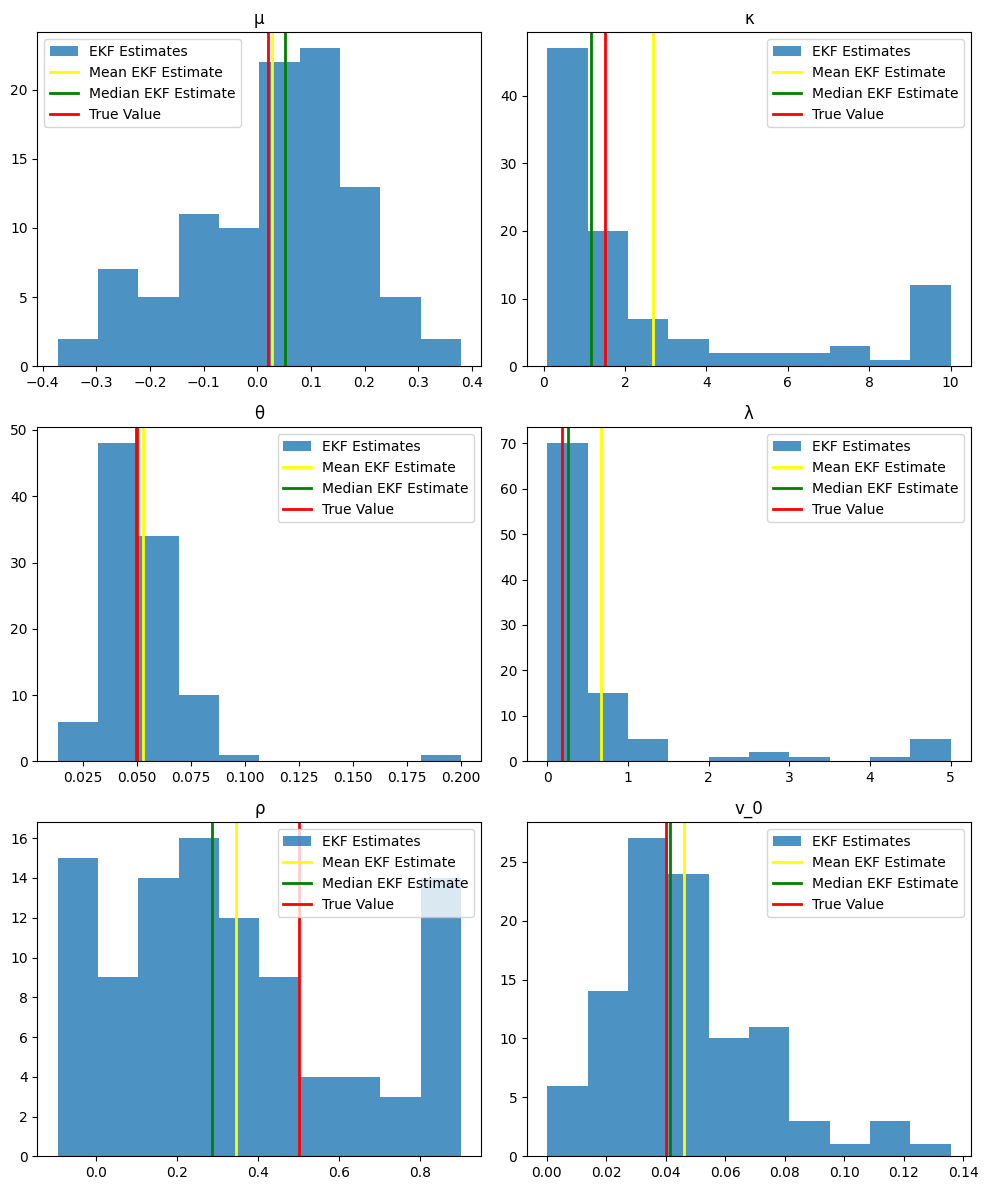

,True Value,Mean EKF Estimate,Median EKF Estimate,St.Dev of EKF Esimates,Lower Bound Hit %,Upper Bound Hit %
μ,0.02,0.027,0.052,0.153,0.0,0.0
κ,1.50,2.693,1.157,3.275,0.0,9.0
θ,0.05,0.053,0.050,0.021,0.0,0.0
λ,0.18,0.664,0.255,1.185,16.0,1.0
ρ,0.50,0.344,0.286,0.299,0.0,6.0
v_0,0.04,0.046,0.042,0.025,1.0,0.0


In [9]:
kf_results_array = np.array(kf_results)

#Output stats
means = []
medians = []
stdevs = []
lower_bounary_hits = []
upper_boundary_hits = []

fig_cols = 2
fig_rows = 3

fig, axs = plt.subplots(fig_rows, fig_cols, figsize=(10, 4*fig_rows))
axs = axs.flatten()

for i, name in enumerate(param_names):

    data = kf_results_array[:,i]

    mean = np.mean(data)
    median = np.median(data)
    stdev = np.std(data)

    lb = lb_list[i]
    ub = ub_list[i]

    lb_hits = np.sum(np.abs(data - lb) <= 1e-4)
    ub_hits = np.sum(np.abs(data - ub) <= 1e-4)

    means.append(mean)
    medians.append(median)
    stdevs.append(stdev)
    lower_bounary_hits.append(lb_hits)
    upper_boundary_hits.append(ub_hits)

    axs[i].hist(data, bins=10, label='EKF Estimates', alpha=0.8)

    axs[i].axvline(mean, linewidth=2, color='yellow', label='Mean EKF Estimate')
    axs[i].axvline(median, linewidth=2, color='green', label='Median EKF Estimate')
    axs[i].axvline(heston_params_dict[name], linewidth=2, color='red', label='True Value')

    axs[i].set_title(name)
    axs[i].legend()

for ax in axs[6:]:
    ax.axis('off')

means = np.array(means)
medians = np.array(medians)
stdevs = np.array(stdevs)
lower_bounary_hits = np.array(lower_bounary_hits)
upper_boundary_hits = np.array(upper_boundary_hits)

plt.tight_layout()
plt.show()


output_table = pd.DataFrame({
    'True Value': [heston_params_dict[x]
                   for x in param_names
                  ],
    'Mean EKF Estimate': np.round(means,3),
    'Median EKF Estimate': np.round(medians,3),
    'St.Dev of EKF Esimates': np.round(stdevs,3),
    'Lower Bound Hit %': np.round(100*lower_bounary_hits / 
                                  num_kf_runs, 1),
    'Upper Bound Hit %': np.round(100*upper_boundary_hits / 
                                  num_kf_runs ,1)
    },
index = param_names
    )

output_table

Looking at the histograms and error table, we see that after 100 draws, certain parameters have been estimated reliably while others have not. We also obtain additional information by observing the shape of the histograms.

For mu, the mean return of the price process, the EKF estimated a mean value of 0.045 and a median of 0.06, compared to a true value of 0.02. The mean value is relatively accurate, but the standard deviation of 0.125 and visual inspection of the histogram indicates that very innacurate values were produced in a large subset of draws. The distribution appears to be roughly Gaussian, with no clear systematic under- or over-estimation.

The mean estimate of kappa is almost exact, while the median is also fairly accurate. However, the standard deviation of estimates indicates that it was not estimated reliably across all runs.

Theta estimation is fairly accurate, with both mean and median close to the true value of 0.05. The standard deviation of 0.099 indicates a fair level of precision. Inspecing the histogram reveals that most estimates cluster around the true value, but a small number of large outliers increases the standard deviation of estimates.

Estimation of lambda, the volatility of volatility, is poor, showing both high bias and variance. This could be due to the white noise terms causing difficulty in estimation.

Though the mean and median of rho estimates are fair, we see a relatively high standard deviation. In addition, the histogram and boundary hit statistics indicate that the optimizer choose the upper bound of rho, 0.9, in 36 out of 100 runs. This results in a biased high estimate of rho and likely points to numeric issues encountered in the optimizer. When rho approaches 1, the correlation matrix becomes near-singular, leading to significant instability in filter estimates.

v_0, the initial variance parameter, shows nearly unbiased estimates with fair precision. Like mu, the distribution of values appears to be roughly Gaussian.

Overall, we can conclude that the Extended Kalman Filter can struggle to estimate true Heston parameter values when ran on only one observation of a full time series. This is particularly true of mu, rho, and kappa. In reality, for estimating Heston parameters for only one stock, it may help to break the entire time series into mulitple parts, then optimize a parameter set over each subset independently. Otherwise, we explore the Particle Filter method to see if estimates improve.

-----

For the particle filter implementation, we make a few minor edits to increase the numeric stability of our estimation. In particular, rather than taking the normal distribution of values, we take log-transformed normal values to better handle inputs, then re-map these outputs to obtain equivalent values. We also enforce proper weights behavior in case of small rounding errors that may prevent the CDF summing to one.

In [24]:
#Take log of normal to increase numeric stability
def log_n(x,m,s):
    
        return (
            -0.5*np.log(2*np.pi)
                - np.log(s)
        - 0.5*((x-m)/s)**2
        )



n_periods = 252*10
dt = (1/252)

def obj_particle_filter(heston_params, y):

    rng = np.random.default_rng(123)

    n_particles = 100

    μ, κ, θ, λ, ρ, v0 = heston_params

    particles = np.full(n_particles, v0)
    w = (1/n_particles) * np.ones(n_particles)
    
    log_lk = 0
    
    for t in range(1, n_periods):

        v_last = np.maximum(particles.copy(), 1e-6)
    
        #Proposal dist
        m_I = (
            # (1 + 0.5*λ*ρ*dt)**-1
             (v_last + κ*(θ-v_last)*dt + λ*ρ*(y[t] 
                - y[t-1] -(μ-0.5*v_last)*dt))
        )

        σ_I = (
            # (1 + 0.5*λ*ρ*dt)**-1
            λ * np.sqrt(v_last*(1-ρ**2)*dt)
        )

        v_t = np.maximum(m_I + σ_I*rng.standard_normal(n_particles), 1e-8)
        v_new = v_t
        

        #Likelihood function
        m_L = y[t-1] + (μ-0.5*v_t)*dt

        σ_L = np.sqrt(v_last*dt)

        log_p_yt = log_n(y[t], m_L, σ_L)

        #Transition density
        m_T = (1 + 0.5*λ*ρ*dt)**-1 * (v_last + κ*(θ - v_last)*dt + 0.5*λ*ρ*v_last*dt)

        σ_T = (1 + 0.5*λ*ρ*dt)**-1 * λ*np.sqrt(v_last*dt)

        log_p_vt = log_n(v_t, m_T, σ_T)

        #Proposal density
        log_π = log_n(v_t, m_I, σ_I)

        #Set weight
        log_w = (
            -np.log(n_particles)
            + log_p_yt
            + log_p_vt
            - log_π
        )
    
        #Add to likelihood
        addition = logsumexp(log_w)

        if not np.isfinite(addition):
            return 1e12
        
        log_lk += addition
    
        #Normalize weights
        w_normalized = np.exp(log_w - addition)
    
        ###Sampling Importance Resampling
        c = np.cumsum(w_normalized)
        #Enforce total cumulative sum is 1 in case of numeric error
        c[-1] = 1

        i = 0
        u_sample = rng.uniform()
        
        for j in range(n_particles):
            u = (1/n_particles) * (u_sample + j)
            
            while u > c[i]:
                i += 1
                
            particles[j] = v_new[i]
            
    return -log_lk

    

In [30]:
def get_pf_estimates(num_runs, lb_list, ub_list):

    heston_params = tuple(heston_params_dict[k] for k in param_names)

    results = []
    
    for n in range(num_runs):

        y = simulate_log_stock_process(
            method='imex',
            S0 = 100,
            n_periods = 252*10, 
            heston_params = heston_params
        )

        #Initialize μ, θ, v_0 from historical estimates
        dy = np.diff(y)
        
        θ_0 = v_0 = np.var(dy) * 252
        μ_0 = np.average(dy)*252 + 0.5*θ_0
        
        κ_0 = 2
        λ_0 = 0.5
        ρ_0 = 0
        
        
        x0 = np.array([μ_0, κ_0, θ_0, 
                       λ_0, ρ_0, v_0])

        bounds = list(zip(lb_list, ub_list))

        start = time.time()
        sol = minimize(
            lambda params: obj_particle_filter(params, y),
            bounds=bounds, x0=x0, method='L-BFGS-B')
        end = time.time()

        results.append(sol.x)
        
        #print(f'Ran iteration {n+1} in {np.round(end-start,1)} seconds')
        if n % 10 == 0:
                print(f'Ran Iteration {n+1}')

    return results

For the Particle Filter, we use the same bounds and initial guesses as for the EKF. We utilize the IMEX discretization of the Heston process to ensure that the PF update does not cancel out certain terms. Similarly to the EKF, we optimize over 100 different samples independently then compare the results.

We additionally choose to use the Sampling Importance Sampling method to avoid the degeneracy problem to regenerate particles with higher weight. This allows for increased numeric stability as well as better state estimation.

In [31]:
num_pf_runs = 50
pf_results = get_pf_estimates(num_pf_runs, lb_list, ub_list)
pf_results_array = np.array(pf_results)

Ran Iteration 1
Ran Iteration 11
Ran Iteration 21
Ran Iteration 31
Ran Iteration 41


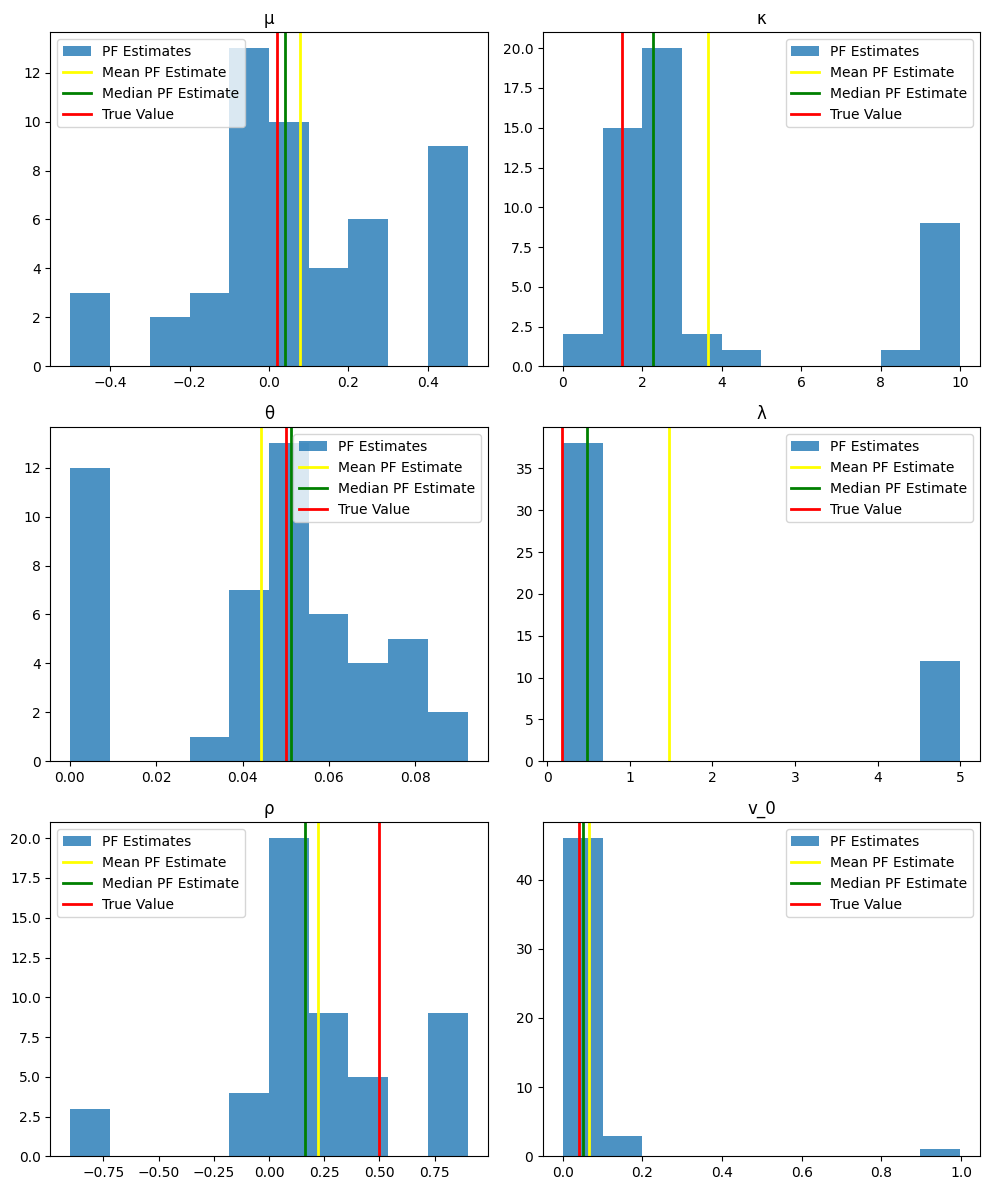

,True Value,Mean PF Estimate,Median PF Estimate,St.Dev of PF Esimates,Lower Bound Hit %,Upper Bound Hit %
μ,0.02,0.078,0.041,0.260,6.0,18.0
κ,1.50,3.657,2.263,3.177,0.0,12.0
θ,0.05,0.044,0.051,0.028,24.0,0.0
λ,0.18,1.478,0.476,1.980,0.0,18.0
ρ,0.50,0.222,0.165,0.422,6.0,18.0
v_0,0.04,0.066,0.050,0.137,18.0,0.0


In [32]:
#Output stats
means = []
medians = []
stdevs = []
lower_bounary_hits = []
upper_boundary_hits = []

fig_cols = 2
fig_rows = 3

fig, axs = plt.subplots(fig_rows, fig_cols, figsize=(10, 4*fig_rows))
axs = axs.flatten()

for i, name in enumerate(param_names):

    data = pf_results_array[:,i]

    mean = np.mean(data)
    median = np.median(data)
    stdev = np.std(data)

    lb = lb_list[i]
    ub = ub_list[i]

    lb_hits = np.sum(np.abs(data - lb) <= 1e-4)
    ub_hits = np.sum(np.abs(data - ub) <= 1e-4)

    means.append(mean)
    medians.append(median)
    stdevs.append(stdev)
    lower_bounary_hits.append(lb_hits)
    upper_boundary_hits.append(ub_hits)

    axs[i].hist(data, bins=10, label='PF Estimates', alpha=0.8)

    axs[i].axvline(mean, linewidth=2, color='yellow', label='Mean PF Estimate')
    axs[i].axvline(median, linewidth=2, color='green', label='Median PF Estimate')
    axs[i].axvline(heston_params_dict[name], linewidth=2, color='red', label='True Value')

    axs[i].set_title(name)
    axs[i].legend()

for ax in axs[6:]:
    ax.axis('off')

means = np.array(means)
medians = np.array(medians)
stdevs = np.array(stdevs)
lower_bounary_hits = np.array(lower_bounary_hits)
upper_boundary_hits = np.array(upper_boundary_hits)

plt.tight_layout()
plt.show()


output_table = pd.DataFrame({
    'True Value': [heston_params_dict[x]
                   for x in param_names
                  ],
    'Mean PF Estimate': np.round(means,3),
    'Median PF Estimate': np.round(medians,3),
    'St.Dev of PF Esimates': np.round(stdevs,3),
    'Lower Bound Hit %': np.round(100*lower_bounary_hits / 
                                  num_pf_runs, 1),
    'Upper Bound Hit %': np.round(100*upper_boundary_hits / 
                                  num_pf_runs ,1)
    },
index = param_names
    )

output_table

When analyzing the particle filter results, we see an number of differences with the EKF results. Interestingly, we see that theta is the only parameter the PF was able to estimate with lower bias and variance than the EKF. All other parameters were estimated more accurately by the EKF. Particularly, the PF was able to estimate kappa almost exactly, as well as producing better estimates of rho and v_0. 

A major red flag in the PF results is the fact that in a significant percentage of runs, certain parameter values hit the upper or lower bounds allowed by the optimizer. This is most noticable for theta, where 21% of optimization runs hit the lower bound, compared to 0% in the EKF. This creates the consideration that the good estimate of theta by the PF may be a coincidence, as boundary hits may be skewing the distribution towards zero.

Despite the Particle Filter allowing for non-parametric approximation of the latent state, giving a theoretical accuracy advantage over EKF, a possible limiting factor was the number of particles used for simulation. The high degree of time complexity of evaluating ten years of daily samples allowed for the simulation of only 50 particles at each time step for efficient computation. Even with vectorized code, the nature of the optimization problem prevents leveraging multi-threading to speed up computation. Given that the code is written in NumPy, which makes use of C, it is likely that running the PF in a faster language such as C++ would not provide much additional benefit. Thus, with a computing power constraint, we have shown in this example that PF can underperform EKF despite the non-parametric benefit.

For better analysis, we could have increased the number of particles simulated at each time step, but as mentioned previously, this introduces heightened considerations of runtime and computational complexity. Additionally, we could have implemented the UKF to obtain a better proposal, then used this output in the PF, concentrating particles in high-likelihood areas and reducing output variance. However, it is likely that combining the UKF with the PF would have further increased the computational complexity.

-----

In conclusion, we highlight the efficiency of the EKF and its ability to handle non-linear systems such as Heston. However, it still struggles by utilizing the Gaussian approximation of the latent variance state, which is inaccurate due to variance being inherently positive. Nevertheless, we see strong estimates for kappa, theta, and v_0, and fair estimates for mu and rho.

Despite the relative underperformance of the PF in this example, we recognize that it has better potential to capture the inherent nonlinearity and non-Gaussian nature of the Heston variance process. This demonstration serves to show that in practice, PF should be implemented with a larger number of particles if computational power allows; otherwise, EKF may perform better.